In [1]:
from __future__ import absolute_import, division, print_function

In [2]:
# License: MIT

In [3]:
%matplotlib inline

## Packages

In [4]:
import numpy as np
import scipy as scipy
import scipy.linalg as linalg

import matplotlib.pyplot as plt

import warnings

# Computational Activity 5
We model Pouiseuille/Couette flow directly and using finite-difference methods

## Part 1
Implement the functions of the flow solutions directly

In [5]:
def Poiseuille(x,z,params):
    G = params[0]
    mu = params[1]
    H = params[2]

    u = G/(2*mu)*z*(H-z)
    
    return u

In [6]:
# set parameters
G = 4
mu = 0.2
H = 2

params = np.array([G,mu,H])

In [7]:
x = np.linspace(0,1,1)
z = np.linspace(0,2,21)
X,Z = np.meshgrid(x,z)

U_P = Poiseuille(X,Z,params)

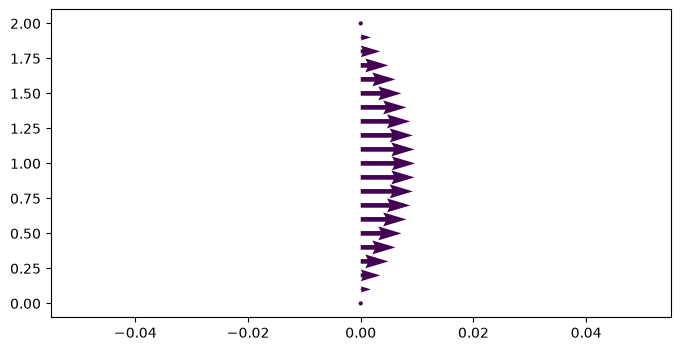

In [8]:
fig = plt.figure(figsize=(8,4))
p = plt.quiver(X,Z,U_P,U_P*0,50)

In [9]:
def Couette(x,z,params):
    G = params[0]
    mu = params[1]
    H = params[2]
    C = params[3]

    u = C/H*z+G/(2*mu)*z*(H-z)
    
    return u

In [10]:
# set parameters
C = 100

params = np.array([G,mu,H,C])

In [11]:
U_C = Couette(X,Z,params)

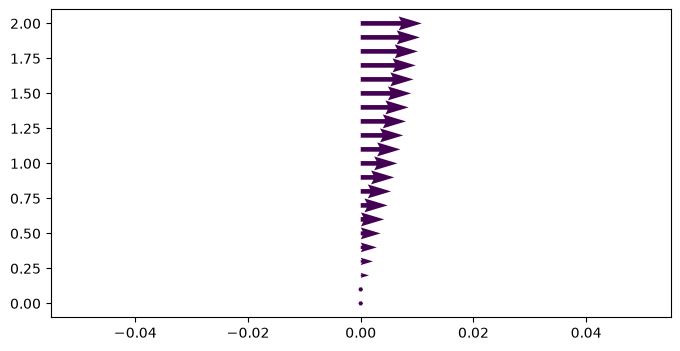

In [12]:
fig = plt.figure(figsize=(8,4))
p = plt.quiver(X,Z,U_C,U_C*0,50)

## Part 2
Approximate ODE solution through finite difference method

In [13]:
def finitediff(z,f,H,A,B):
    # look for solutions of form Mu=h^2f
    N = np.shape(z)[0]
    z_int = z[1:-1]
    N_int = np.shape(z_int)[0]
    h = H/(N-1)
    
    M = np.diag(np.ones(N-3),-1) + np.diag(-2*np.ones(N-2),0) + np.diag(np.ones(N-3),1) 

    b = h**2*f(z_int)
    b[0] = b[0]-A
    b[-1] = b[-1]-B
    u_int = linalg.solve(M,b)

    u = np.empty(np.shape(z))
    u[1:-1] = u_int
    u[0] = A
    u[-1] = B
    
    return u

In [14]:
f = lambda z: -G/mu+np.zeros(np.shape(z))
A = 0. 
B = 0.

U_P_FD = finitediff(z,f,H,A,B)

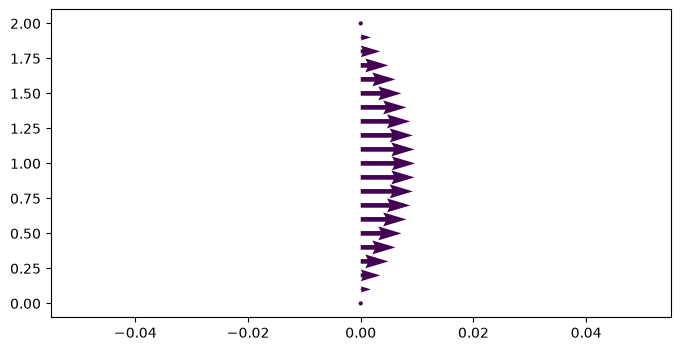

In [15]:
fig = plt.figure(figsize=(8,4))
plt.quiver(X,Z,U_P_FD,np.zeros(np.shape(U_P_FD)),50)#,cmap='coolwarm')
plt.show()

In [16]:
A = 0
B = C

U_C_FD = finitediff(z,f,H,A,B)

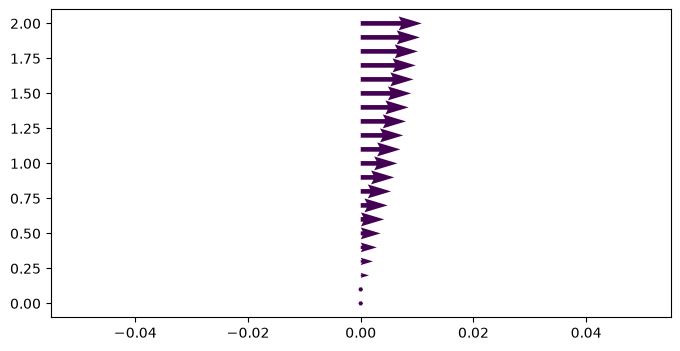

In [17]:
fig = plt.figure(figsize=(8,4))
plt.quiver(X,Z,U_C_FD,U_C_FD*0,50)#,cmap='coolwarm')
plt.show()

### Compare approximation

In [23]:
error_P = np.abs(U_P[:,0]-U_P_FD)
error_C = np.abs(U_C[:,0]-U_C_FD)

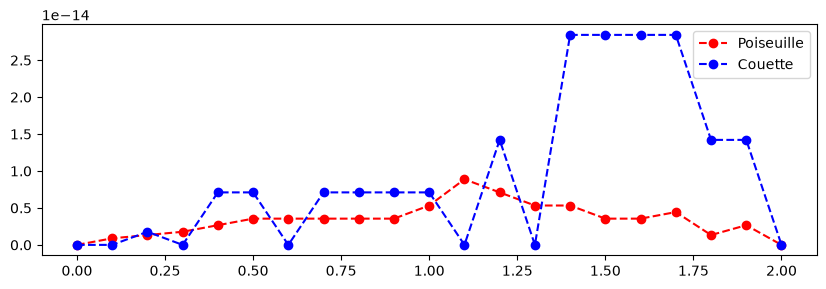

In [34]:
fig = plt.figure(figsize=(10,3))
plt.plot(z,error_P,'ro--')
plt.plot(z,error_C,'bo--')
plt.legend(["Poiseuille","Couette"])
plt.show()

It's quite good

### Bonus: try a different form for $f(z)$ and different boundary conditions

In [43]:
f = lambda z: -G/mu*z**4
A = -20
B = 10
U_FD_bonus = finitediff(z,f,H,A,B)

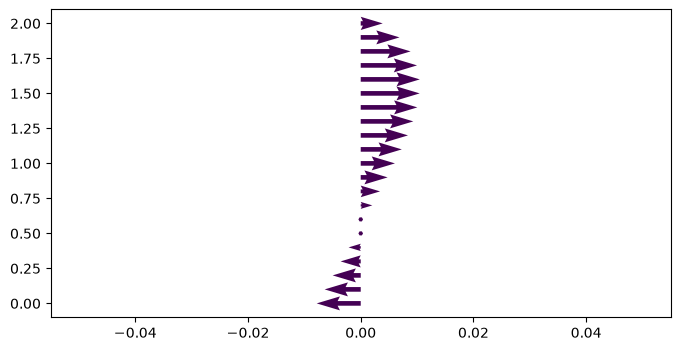

In [44]:
fig = plt.figure(figsize=(8,4))
plt.quiver(X,Z,U_FD_bonus,U_FD_bonus*0,50)

## Part 3
Approximate PDE as solution to forced ODE

In [81]:
def ODEsys(t,u,params):
    G = params[0]
    nu = params[1]
    H = params[2]
    A = params[3]
    B = params[4]

    N = np.shape(u)[0]
    u_int = u[1:-1]
    N_int = np.shape(u_int)[0]
    h = H/(N-1)
    
    M = np.diag(np.ones(N_int-1),-1) + np.diag(-2*np.ones(N_int),0) + np.diag(np.ones(N_int-1),1)

    b = -G/mu + np.zeros(np.shape(u_int)) + 10*np.sin(t*np.pi)
    b[0] = b[0]-A*nu/h**2
    b[-1] = b[-1]-B*nu/h**2

    dudt = np.empty(np.shape(z))
    
    dudt_int = np.matmul(M*nu/(h**2),u_int)-b
    dudt[1:-1] = dudt_int
    
    dudt[0] = 0
    dudt[-1] = 0

    return dudt

### Poiseuille flow

In [85]:
# boundary conditions
A = 0.
B = 0.

# set parameters
params = np.array([G,mu,H,A,B])

# set start and end times
tspan = [0,10]
t_eval = np.linspace(0,10,1000)

# set initial condition vector
N = np.shape(z)[0]
u0 = np.zeros(N)
u0[0] = u0[0] + A
u0[N-1] = u0[N-1] + B

sol = scipy.integrate.solve_ivp(lambda t,u:ODEsys(t,u,params),tspan,u0,t_eval=t_eval)

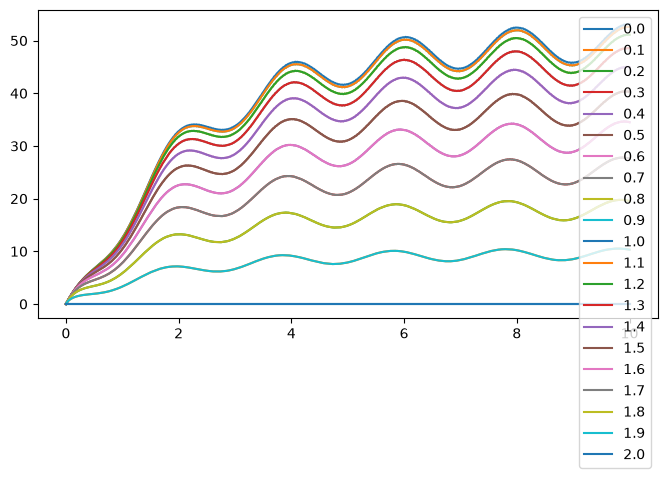

In [86]:
fig = plt.figure(figsize=(8,4))
plt.plot(sol.t,sol.y.T)
plt.legend(np.round(z,2))
plt.show()

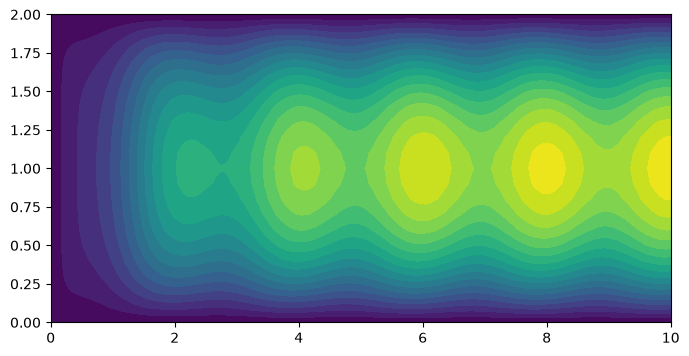

In [87]:
t_mesh,z2_mesh = np.meshgrid(t_eval,z)
fig = plt.figure(figsize=(8,4))
plt.contourf(t_mesh,z2_mesh,sol.y,20)

### Couette flow

In [92]:
# boundary conditions
A = 0.
B = 100.

# set parameters
params = np.array([G,mu,H,A,B])

# set start and end times
tspan = [0,10]
t_eval = np.linspace(0,10,1000)

# set initial condition vector
N = np.shape(z)[0]
u0 = np.zeros(N)
u0[0] = u0[0] + A
u0[N-1] = u0[N-1] + B

sol = scipy.integrate.solve_ivp(lambda t,u:ODEsys(t,u,params),tspan,u0,t_eval=t_eval)

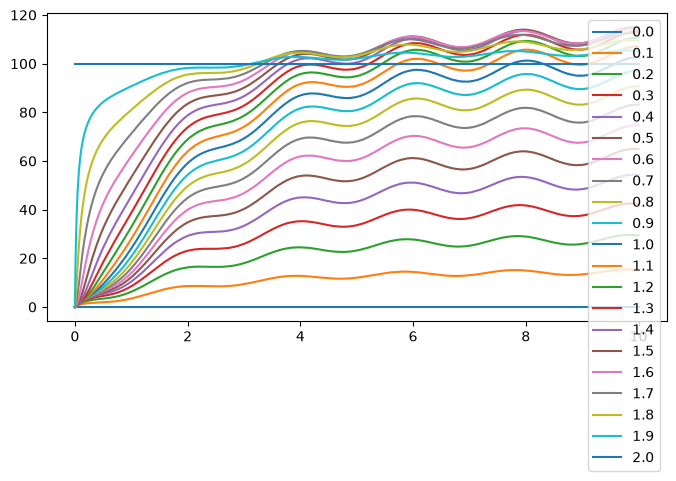

In [93]:
fig = plt.figure(figsize=(8,4))
plt.plot(sol.t,sol.y.T)
plt.legend(np.round(z,2))
plt.show()

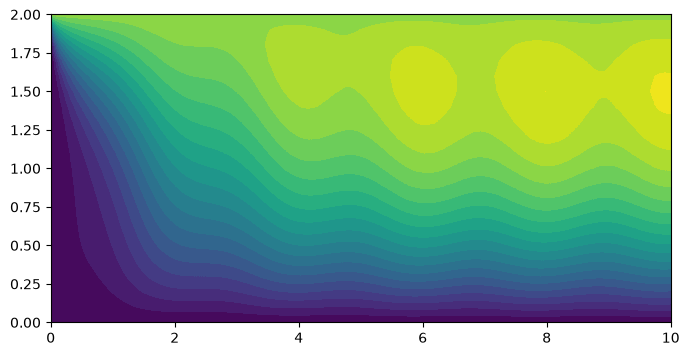

In [94]:
t_mesh,z2_mesh = np.meshgrid(t_eval,z)
fig = plt.figure(figsize=(8,4))
plt.contourf(t_mesh,z2_mesh,sol.y,20)